# Assignment 2 2AMM10 2025-2026

## Group: [Name Editing]
### Member 1: [Chang Qin]
### Member 2: [Annebel Hattingh-Haasbroek]
### Member 3: [Alexandru Vasu]

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch.utils.data import Dataset
from torchvision import transforms

import copy
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score
import random
import numpy as np
import pandas as pd
from collections import defaultdict
from transformers import SwinModel
from tqdm import tqdm

## Global Variables ##
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DATA_DIR = "./data"
DROWSY_DATASET_DIR = Path(
    DATA_DIR, "drowsy_graph_dataset"
)  # Path to the drowsy dataset
OBJ_CLS_DATASET_DIR = Path(
    DATA_DIR, "bdd8cls_balanced_300_30"
)  # Path to the object classification dataset
DEVICE = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else (
        torch.device("mps")
        if torch.backends.mps.is_available()
        else torch.device("cpu")
    )
)

C:\Users\20223084\.conda\envs\dl_code\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Task 1

In [2]:
class DrowsyFaceGraphDataset(Dataset):
    def __init__(self, root, split="train"):
        self.root = Path(root)
        self.split = split

        data_path = self.root / f"{split}.pt"
        class_to_id_path = self.root / "class_to_id.json"
        id_to_class_path = self.root / "id_to_class.json"

        if not data_path.exists():
            raise FileNotFoundError(f"Could not find {data_path}")

        self.graphs = torch.load(data_path, weights_only=False)

        with open(class_to_id_path, "r") as f:
            self.class_to_id = json.load(f)

        with open(id_to_class_path, "r") as f:
            self.id_to_class = json.load(f)

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        return self.graphs[idx]


train_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="train")
test_dataset = DrowsyFaceGraphDataset(root=DROWSY_DATASET_DIR, split="test")
class_to_id: dict = train_dataset.class_to_id
id_to_class: dict = train_dataset.id_to_class

##

<Axes: >

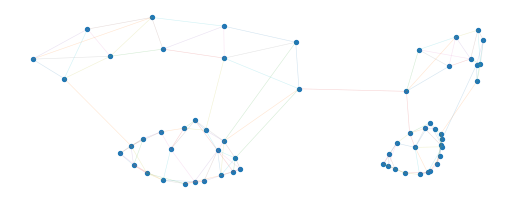

In [3]:
# Visualization helper
def plot_face_graph(
    graph, ax=None, title=None, node_size=8, edge_alpha=0.20, edge_width=0.4
):
    """Plot one face graph using its 2D normalized landmark coordinates."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 4))

    coords = graph.x.cpu().numpy()  # Nodes of the Graph
    edge_index = graph.edge_index.cpu().numpy()  # Edges of the Graph

    xy = coords[:, :2]

    seen = set()
    for i, j in edge_index.T:
        a, b = int(i), int(j)
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        ax.plot(
            [xy[a, 0], xy[b, 0]],
            [xy[a, 1], xy[b, 1]],
            linewidth=edge_width,
            alpha=edge_alpha,
        )

    ax.scatter(xy[:, 0], xy[:, 1], s=node_size)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

    return ax


fig, ax = plt.subplots()
idx = random.randint(0, len(train_dataset) - 1)
graph = train_dataset[idx]
x, y = graph.x, graph.y
plot_face_graph(graph, ax)


# Understanding the samples
# 1) graph.x: (Num_nodes, 3) matrix. The coordinates (x1,x2,x3) of the facial landmarks, normalized to [-1,1]. Those are the node features of the graph.
# 2) graph.edge_index: (2, Num_edges) matrix. The edges of the graph, where each column (i,j) represents an edge from node i to node j.
# 3) graph.y: The label of the graph, where 0 means "alert" and 1 means "drowsy". This is the target variable we want to predict.
# 4) You can safely ignore the other 2 attributes of the graph (source_index and eye_openness) for this assignment.
# For completeness, eye_openness is a score in [0,1] that indicates how open the eyes are, and source_index is an index corresponding to the sample index with respect to the original dataset before graph construction.

In [4]:
# I set the seed again here so that rerunning Task 1 gives similar results.
# The exact numbers can still change a little depending on the device.
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# The PyG DataLoader combines several small face graphs into one batch.
# Each node still keeps a graph id in data.batch, which is used later for pooling.
device = DEVICE
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# I quickly inspect one sample to make sure the feature size and graph format are as expected.
sample = train_dataset[0]
in_dim = sample.x.shape[1]
print(f"Number of training graphs: {len(train_dataset)}")
print(f"Number of test graphs: {len(test_dataset)}")
print(f"Node feature shape: {sample.x.shape}")
print(f"Edge index shape: {sample.edge_index.shape}")
print(f"Sample label: {sample.y.item()}")


Number of training graphs: 400
Number of test graphs: 100
Node feature shape: torch.Size([60, 3])
Edge index shape: torch.Size([2, 304])
Sample label: 1


In [5]:
# I normalize the coordinates inside each graph so the model focuses more on face shape.
# This also makes training a bit more stable for the small dataset.
def normalize_graph_features(x, batch):
    num_graphs = int(batch.max().item()) + 1
    counts = torch.bincount(batch, minlength=num_graphs).float().unsqueeze(1).to(x.device)

    mean = torch.zeros(num_graphs, x.size(1), device=x.device)
    mean.index_add_(0, batch, x)
    mean = mean / counts.clamp_min(1.0)

    centered = x - mean[batch]
    var = torch.zeros(num_graphs, x.size(1), device=x.device)
    var.index_add_(0, batch, centered.pow(2))
    std = torch.sqrt(var / counts.clamp_min(1.0) + 1e-6)
    return centered / std[batch]


# This is a simple GraphSAGE-like layer written with plain PyTorch operations.
# For every node, it averages messages from its neighbours and combines them with the node itself.
class SimpleGraphLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.update = nn.Sequential(
            nn.Linear(2 * in_dim, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim),
        )

    def forward(self, x, edge_index):
        src, dst = edge_index
        messages = x[src]
        agg = torch.zeros_like(x)
        agg.index_add_(0, dst, messages)

        degree = torch.zeros(x.size(0), 1, device=x.device)
        degree.index_add_(0, dst, torch.ones(dst.size(0), 1, device=x.device))
        mean_neighbours = agg / degree.clamp_min(1.0)

        out = self.update(torch.cat([x, mean_neighbours], dim=1))
        return F.relu(out)


# The full model first embeds node coordinates, then applies message passing.
# After that, mean and max pooling make one vector for each whole face graph.
class DrowsyGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_classes=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.layers = nn.ModuleList(
            [SimpleGraphLayer(hidden_dim, hidden_dim) for _ in range(3)]
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, data):
        x = normalize_graph_features(data.x.float(), data.batch)
        x = F.relu(self.encoder(x))
        for layer in self.layers:
            x = layer(x, data.edge_index)
            x = self.dropout(x)
        graph_embedding = graph_mean_max_pool(x, data.batch)
        return self.classifier(graph_embedding)


# This pooling step is permutation-invariant, so it does not depend on node order.
# I use both mean and max because they capture slightly different graph information.
def graph_mean_max_pool(x, batch):
    num_graphs = int(batch.max().item()) + 1
    counts = torch.bincount(batch, minlength=num_graphs).float().unsqueeze(1).to(x.device)

    graph_mean = torch.zeros(num_graphs, x.size(1), device=x.device)
    graph_mean.index_add_(0, batch, x)
    graph_mean = graph_mean / counts.clamp_min(1.0)

    graph_max = []
    for graph_idx in range(num_graphs):
        graph_max.append(x[batch == graph_idx].max(dim=0).values)
    graph_max = torch.stack(graph_max, dim=0)

    return torch.cat([graph_mean, graph_max], dim=1)


In [6]:
# Drowsy is the positive class here, so I compute recall and precision for label 1.
# I also keep TP/FP/FN/TN to show how the final metrics were calculated.
def compute_drowsy_metrics(y_true, y_pred):
    y_true = torch.cat(y_true).cpu()
    y_pred = torch.cat(y_pred).cpu()

    tp = ((y_pred == 1) & (y_true == 1)).sum().item()
    fn = ((y_pred == 0) & (y_true == 1)).sum().item()
    fp = ((y_pred == 1) & (y_true == 0)).sum().item()
    tn = ((y_pred == 0) & (y_true == 0)).sum().item()
    eps = 1e-8
    recall = tp / (tp + fn + eps)
    precision = tp / (tp + fp + eps)
    counts = {"tp": tp, "fp": fp, "fn": fn, "tn": tn}
    return recall, precision, counts


# One training epoch loops over the training graphs and updates the model weights.
# The returned loss is averaged over graphs, not over batches.
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_graphs = 0

    for batch in loader:
        batch = batch.to(device)
        y = batch.y.long().view(-1)

        optimizer.zero_grad()
        logits = model(batch)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_graphs += y.size(0)

    return total_loss / total_graphs


# Evaluation is the same forward pass, but without gradient updates.
# I collect all predictions so recall and precision are computed on the full test set.
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_graphs = 0
    all_true = []
    all_pred = []

    for batch in loader:
        batch = batch.to(device)
        y = batch.y.long().view(-1)
        logits = model(batch)
        loss = criterion(logits, y)
        pred = logits.argmax(dim=1)

        total_loss += loss.item() * y.size(0)
        total_graphs += y.size(0)
        all_true.append(y.detach().cpu())
        all_pred.append(pred.detach().cpu())

    recall, precision, counts = compute_drowsy_metrics(all_true, all_pred)
    return total_loss / total_graphs, recall, precision, counts


In [7]:
# I keep the model small because there are only 400 training graphs.
# CrossEntropyLoss is used because the model outputs two logits: awake and drowsy.
model = DrowsyGNN(in_dim=in_dim, hidden_dim=64, num_classes=2, dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# I store the losses and metrics at every epoch so they can be plotted afterwards.
history = {"train_loss": [], "test_loss": [], "recall": [], "precision": []}
final_counts = None
epochs = 60

for epoch in range(1, epochs+1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, recall, precision, counts = evaluate(model, test_loader, criterion, device)
    final_counts = counts

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["recall"].append(recall)
    history["precision"].append(precision)

    # Printing every 10 epochs is enough to see progress without too much output.
    if epoch == 0 or epoch % 10 == 0:
        print(
            f"epoch {epoch:03d} | train loss {train_loss:.4f} | "
            f"test loss {test_loss:.4f} | recall {recall:.4f} | precision {precision:.4f}"
        )

final_test_loss = history["test_loss"][-1]
final_recall = history["recall"][-1]
final_precision = history["precision"][-1]

epoch 010 | train loss 0.6027 | test loss 0.6793 | recall 0.5000 | precision 0.6098
epoch 020 | train loss 0.5625 | test loss 0.6845 | recall 0.5200 | precision 0.6500
epoch 030 | train loss 0.4725 | test loss 0.5776 | recall 0.7200 | precision 0.7347
epoch 040 | train loss 0.4279 | test loss 0.5228 | recall 0.7400 | precision 0.7872
epoch 050 | train loss 0.2982 | test loss 0.3646 | recall 0.8200 | precision 0.8723
epoch 060 | train loss 0.2470 | test loss 0.3319 | recall 0.9000 | precision 0.8182


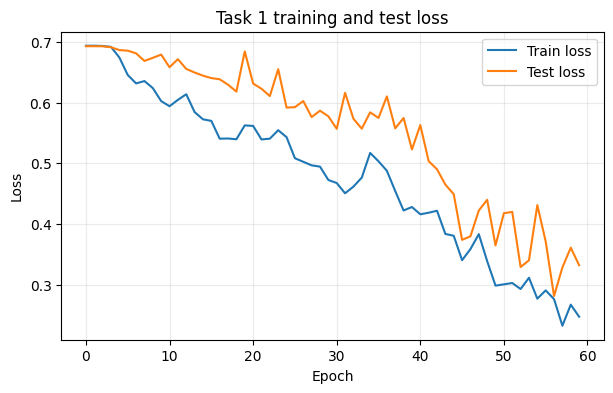

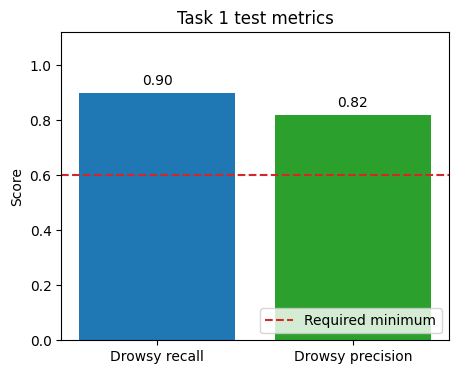

Final test loss: 0.3319
Drowsy recall: 0.9000
Drowsy precision: 0.8182
Confusion counts: TP=45, FP=10, FN=5, TN=40


In [8]:
# This plot compares training and test loss over the full training run.
# A small gap near the end is expected because the model keeps fitting the training set.
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["test_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 1 training and test loss")
plt.legend()
plt.grid(alpha=0.25)
plt.savefig(
        "task1_lineplot_losses.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

# The metric plot shows the two required drowsy-class metrics.
# The dashed line is the assignment threshold that both bars should pass.
plt.figure(figsize=(5, 4))
metric_names = ["Drowsy recall", "Drowsy precision"]
metric_values = [final_recall, final_precision]
plt.bar(metric_names, metric_values, color=["tab:blue", "tab:green"])
plt.axhline(0.6, linestyle="--", color="tab:red", label="Required minimum")
plt.ylim(0, 1.12)
plt.ylabel("Score")
plt.title("Task 1 test metrics")
plt.legend(loc="lower right")
for i, value in enumerate(metric_values):
    plt.text(i, value + 0.03, f"{value:.2f}", ha="center")

plt.savefig(
        "task1_barplot_results.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

# Final numbers are printed so they are easy to report in the PDF/export.
print(f"Final test loss: {final_test_loss:.4f}")
print(f"Drowsy recall: {final_recall:.4f}")
print(f"Drowsy precision: {final_precision:.4f}")
print(
    "Confusion counts: "
    f"TP={final_counts['tp']}, FP={final_counts['fp']}, "
    f"FN={final_counts['fn']}, TN={final_counts['tn']}"
)


# Task 2

In [9]:
class _BaseImageClassificationDataset(Dataset):
    """
    Base dataset for image classification datasets stored as:

        dataset_dir/
            class_to_id.json
            id_to_class.json
            train/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
            test/
                000000.jpg
                ...
                labels.csv
                [metadata.csv]
    """

    def __init__(
        self,
        dataset_dir,
        split="train",
        img_transform=None,
    ):
        super().__init__()
        self.dataset_dir = Path(dataset_dir)
        self.split = split
        self.img_transform = img_transform

        if self.split not in {"train", "test"}:
            raise ValueError(f"split must be 'train' or 'test', got: {self.split}")

        self.split_dir = self.dataset_dir / self.split
        self.labels_path = self.split_dir / "labels.csv"
        self.class_to_id_path = self.dataset_dir / "class_to_id.json"
        self.id_to_class_path = self.dataset_dir / "id_to_class.json"

        if not self.dataset_dir.exists():
            raise FileNotFoundError(f"Dataset directory not found: {self.dataset_dir}")
        if not self.split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {self.split_dir}")
        if not self.labels_path.exists():
            raise FileNotFoundError(f"labels.csv not found: {self.labels_path}")
        if not self.class_to_id_path.exists():
            raise FileNotFoundError(
                f"class_to_id.json not found: {self.class_to_id_path}"
            )
        if not self.id_to_class_path.exists():
            raise FileNotFoundError(
                f"id_to_class.json not found: {self.id_to_class_path}"
            )

        with open(self.class_to_id_path, "r") as fp:
            self.class_to_id = json.load(fp)

        with open(self.id_to_class_path, "r") as fp:
            self.id_to_class = json.load(fp)

        # Normalize keys for convenience
        self.id_to_class = {int(k): v for k, v in self.id_to_class.items()}
        self.num_classes = len(self.class_to_id)
        self.classes = [self.id_to_class[i] for i in range(self.num_classes)]

        self.labels = (
            pd.read_csv(self.labels_path, header=None).iloc[:, 0].astype(int).tolist()
        )

        self.img_paths = sorted(
            [
                p
                for p in self.split_dir.iterdir()
                if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ],
            key=lambda p: p.name,
        )

        if len(self.img_paths) != len(self.labels):
            raise ValueError(
                f"Mismatch between number of images ({len(self.img_paths)}) and "
                f"labels ({len(self.labels)}) in split '{self.split}'."
            )

    def __len__(self):
        return len(self.labels)

    def _load_image(self, img_path):
        with Image.open(img_path) as img:
            img = img.convert("RGB")
            if self.img_transform is not None:
                img = self.img_transform(img)
            return img

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        image = self._load_image(img_path)
        label = self.labels[idx]

        return image, label


class BDDObjectClassificationDataset(_BaseImageClassificationDataset):
    """
    Dataset for the cropped-object classification dataset.

    Returns:
        image, label
    or:
        image, label, metadata   (if return_metadata=True)

    Notes:
        - img_transform defaults to None.
        - The user is responsible for resizing / tensor conversion.
    """

    pass


class PatchShuffle:
    def __init__(self, patch_size=8):
        self.p = patch_size

    def __call__(self, img):
        # Input: [C, H, W]
        c, h, w = img.shape
        p = self.p

        # 1. Unfold image into patches [C, H/p, W/p, p, p]
        patches = img.unfold(1, p, p).unfold(2, p, p)
        num_h = h // p
        num_w = w // p

        # 2. Reshape to [num_patches, C, p, p]
        patches = patches.contiguous().view(c, -1, p, p).permute(1, 0, 2, 3)

        # 3. Shuffle the patches along the first dimension
        idx = torch.randperm(patches.size(0))
        patches = patches[idx]

        # 4. Reshape back to original image dimensions
        # We need to rearrange from [num_h*num_w, C, p, p] back to [C, H, W]
        patches = patches.view(num_h, num_w, c, p, p).permute(2, 0, 3, 1, 4)
        shuffled_img = patches.contiguous().view(c, h, w)

        return shuffled_img

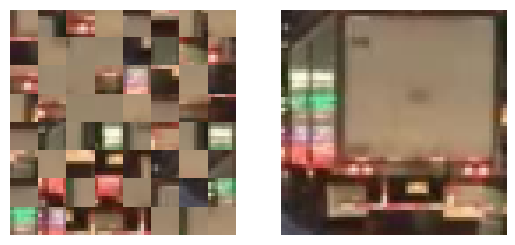

In [10]:
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=None,  # Fill train image transforms
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=None,  # Fill test image transforms
)

### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###
from torchvision.transforms import Compose, ToTensor, Resize
from torchvision.transforms import functional as vf
import matplotlib.pyplot as plt

vis_dataset_noisy = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor(), PatchShuffle(patch_size=8)]),
)
vis_dataset_clean = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=Compose([Resize((64, 64)), ToTensor()]),
)
fig, ax = plt.subplots(1, 2)
img_noisy, label = vis_dataset_noisy[16]
img_clean, label = vis_dataset_clean[16]
ax[0].imshow(vf.to_pil_image(img_noisy))
ax[1].imshow(vf.to_pil_image(img_clean))
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
    a.set_frame_on(False)
### See how Patch Shuffle affects an image: CODE MEANT FOR ILLUSTRATION ###

In [11]:
class Lambda(nn.Module):
    def __init__(self, func, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.func = func
    
    def forward(self, x):
        return self.func(x)

# We used a vision transformer architecture for learning image representations from
# patch tokens. This architecture was chosen as the task involves classifying corrupetd images
# with shuffled patches. Since the model processes the image as a sequential projection of patches,
# it is perfectly suited for the given task with minimal architectural changes.
class VisionTransformer(nn.Module):
    def __init__(self, n_classes, patch_size = 8, embedding_dim = 64, num_heads = 4, mlp_dim = 128, depth = 4, dropout = 0.3):
        super().__init__()
        # This layer transforms patches into embeddings using a convolution that takes a kernel_size of
        # (patch_size x patch_size). The resulting embeddings are flattened because the transformer
        # expects 1 dimensional vector inputs. 
        self.patch_embedding = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=embedding_dim, kernel_size=patch_size, stride=patch_size),
            nn.Flatten(start_dim=-2),
            Lambda(lambda x: x.transpose(-2, -1)),
        )

        # Learnable CLS token added to the patch sequence. After self-attention,
        # its final representation is used as the global image representation for classification.
        self.cls_token = nn.Parameter(torch.randn(1, 1, embedding_dim) * 0.02)

        # Single Transformer block used to model relationships between patch tokens. It uses self-attention with multiple heads to create
        # multiple relations between tokens, followed by an MLP (which is a small neural network that processes each token representation independently).
        transformer_layer = nn.TransformerEncoderLayer(d_model=embedding_dim, nhead=num_heads, dim_feedforward=mlp_dim, 
                                                       dropout=dropout, activation="gelu", norm_first=True, batch_first=True)

        self.transformer = nn.TransformerEncoder(transformer_layer, num_layers=depth)

        # Final classification layer -> Outputs logits
        self.classification = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, n_classes)
        )
    
    def forward(self, x):
        patch_embedding = self.patch_embedding(x)

        batch_size = patch_embedding.size(0)

        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        patches = torch.cat([cls_tokens, patch_embedding], dim=1)

        output = self.transformer(patches)

        cls_output = output[:, 0]

        return self.classification(cls_output)

In [12]:
train_task2 = True # Set to false for loading saved model
infer_task2 = True  

In [21]:
# Model trainer that uses a checkpointing strategy to keep the best performing
# model during training. 
class VisionTransformerTrainer():
    def __init__(
        self,
        model: torch.nn.Module,
        device: torch.device,
        criterion: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        training_DataLoader: torch.utils.data.DataLoader,
        validation_DataLoader: torch.utils.data.DataLoader,
        epochs: int,
        criterion_validation: torch.nn.Module = None,
        checkpoint: bool = False,
        checkpoint_path: str = "best_vit_model.pt",
    ):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.device = device
        self.epochs = epochs
        self.checkpoint = checkpoint
        if self.checkpoint:
            self.checkpoint_path = checkpoint_path

        if criterion_validation is None:
            self.criterion_validation = criterion
        else:
            self.criterion_validation = criterion_validation

    def run_trainer(self):
        best_val_acc = 0.0
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_state = None

        for epoch in tqdm(range(self.epochs)):
            self.model.train()

            train_losses = []
            correct = 0
            total = 0

            for batch in self.training_DataLoader:
                x, label_x = batch

                input = x.to(self.device)
                label_target = label_x.to(self.device).long()

                self.optimizer.zero_grad()

                out = self.model(input)
                loss = self.criterion(out, label_target)

                loss.backward()
                self.optimizer.step()

                train_losses.append(loss.item())

                preds = out.argmax(dim=1)
                correct += (preds == label_target).sum().item()
                total += label_target.size(0)

            train_loss = np.mean(train_losses)
            train_acc = correct / total

            self.model.eval()

            valid_losses = []
            valid_correct = 0
            valid_total = 0

            with torch.no_grad():
                for batch in self.validation_DataLoader:
                    x, label_x = batch

                    input = x.to(self.device)
                    label_target = label_x.to(self.device).long()

                    out = self.model(input)
                    loss = self.criterion_validation(out, label_target)

                    valid_losses.append(loss.item())

                    preds = out.argmax(dim=1)
                    valid_correct += (preds == label_target).sum().item()
                    valid_total += label_target.size(0)

            val_loss = np.mean(valid_losses)
            val_acc = valid_correct / max(valid_total, 1)

            if self.checkpoint and val_acc > best_val_acc:
                best_val_acc = val_acc
                best_val_loss = val_loss
                best_epoch = epoch + 1

                best_model_state = copy.deepcopy(self.model.state_dict())

                torch.save({
                    "epoch": best_epoch,
                    "model_state_dict": self.model.state_dict(),
                    "optimizer_state_dict": self.optimizer.state_dict(),
                    "val_acc": best_val_acc,
                    "val_loss": best_val_loss,
                }, self.checkpoint_path)

            print(
                f"EPOCH: {epoch + 1:0>{len(str(self.epochs))}}/{self.epochs} "
                f"LOSS: {train_loss:.4f} "
                f"VAL-LOSS: {val_loss:.4f}"
            )
            print(f"ACCURACY: {train_acc:.4f}")
            print(f"VAL-ACCURACY: {val_acc:.4f}")

        print(f"Training finished.")

        if self.checkpoint and best_model_state is not None :
            self.model.load_state_dict(best_model_state)
            print(f"Best model loaded from epoch: {best_epoch} with val accuracy: {best_val_acc}.")

    def load_last_model(self):
        checkpoint = torch.load(self.checkpoint_path, map_location=DEVICE, weights_only=False)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        print("Last model loaded.")

In [22]:
# Dataset preparation
# SAME FOR TASK 2 AND 3
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets with transformations (uniform sizing)
train_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="train",
    img_transform=transform, 
)

test_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=transform, 
)

validate_dataset = BDDObjectClassificationDataset(
    dataset_dir=OBJ_CLS_DATASET_DIR,
    split="test",
    img_transform=transform, 
)

In [23]:
def evaluate_per_class(model, loader, class_names, labels, visualize = False):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE).long()

            out = model(x)
            preds = out.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    per_class_precision = []
    per_class_recall = []

    for label in set(labels):
        tp = np.sum((all_preds == label) & (all_labels == label))
        fp = np.sum((all_preds == label) & (all_labels != label))
        fn = np.sum((all_preds != label) & (all_labels == label))
    
        if tp + fp == 0:
            precision = 0.0
        else:
            precision = tp / (tp + fp)

        if tp + fn == 0:
            recall = 0.0
        else:
            recall = tp / (tp + fn)

        per_class_precision.append(precision)
        per_class_recall.append(recall)

        if visualize:
            print(f"{class_names[label]:15s} | Precision: {precision:.4f} | Recall: {recall:.4f}")

    # Visualization in a single figure
    if visualize:

        x = np.arange(n_classes)
        width = 0.35

        plt.figure(figsize=(12, 6))

        plt.bar(x - width / 2, per_class_precision, width, label="Precision")
        plt.bar(x + width / 2, per_class_recall, width, label="Recall")

        plt.xticks(x, class_names)
        plt.ylim(0, 1)
        plt.ylabel("Score")
        plt.title("Per-class Precision and Recall")
        plt.legend()
        plt.tight_layout()
        plt.savefig("per_class_precision_recall.png", dpi=300, bbox_inches="tight")
        plt.show()
    
    return per_class_precision, per_class_recall


def agregate_per_class_metrics(per_class_precision, per_class_recall):
    precision_macro = np.mean(per_class_precision)
    recall_macro = np.mean(per_class_recall)

    print()
    print(f"Macro precision: {precision_macro:.4f}")
    print(f"Macro recall:    {recall_macro:.4f}")

    return precision_macro, recall_macro

In [24]:
train_data_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_data_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

patch_size = train_dataset[0][0].size(-1) // 8
n_classes = len(set(train_dataset.labels))

In [25]:
# Based on experimental observations, I arrived at the conclusion that a smaller model performs better for the given task. 
# Larger models tend to overfit, most likely due to the small size of the dataset. Another measure used to reduce overfitting
# is increasing weight decay and dropout. Weight decay penalizes large model weights and dropout randomly disables part of
# the activations during training. Further experiments could be performed to arrive at a better model, but as of its current
# configuration, this model achieves a training accuracy of ~0.60 and test accuracy between 0.45 and 0.5.
model = VisionTransformer(n_classes=n_classes, patch_size=patch_size, embedding_dim=64, num_heads=4, mlp_dim=256, depth=2, dropout=0.25).to(DEVICE)

# This loss function is used as the model outputs logits. It is also the standard criterion for single-labele multi-class classification.
criterion = nn.CrossEntropyLoss()

# AdamW optimizer with a small learning rate for stable training.
# Weight decay provides regularization to reduce overfitting.
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=2e-3)


trainer = VisionTransformerTrainer(
    model,
    DEVICE,
    criterion,
    optimizer,
    train_data_loader,
    test_data_loader,
    epochs=100,
    checkpoint_path="best_vit_model_v2.pt",
    checkpoint=True
)

C:\Users\20223084\AppData\Local\Temp\ipykernel_19980\3351505348.py:34: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(transformer_layer, num_layers=depth)


In [26]:
if train_task2:
    trainer.run_trainer()
else:
    trainer.load_last_model()

  1%|▊                                                                                 | 1/100 [00:06<09:57,  6.03s/it]

EPOCH: 001/100 LOSS: 2.0779 VAL-LOSS: 1.9713
ACCURACY: 0.1675
VAL-ACCURACY: 0.2125


  2%|█▋                                                                                | 2/100 [00:10<08:24,  5.15s/it]

EPOCH: 002/100 LOSS: 2.0223 VAL-LOSS: 1.9584
ACCURACY: 0.1900
VAL-ACCURACY: 0.2417


  3%|██▍                                                                               | 3/100 [00:15<07:54,  4.89s/it]

...

EPOCH: 098/100 LOSS: 1.2230 VAL-LOSS: 1.6498
ACCURACY: 0.5379
VAL-ACCURACY: 0.4417


 99%|████████████████████████████████████████████████████████████████████████████████▏| 99/100 [08:50<00:05,  5.62s/it]

EPOCH: 099/100 LOSS: 1.2317 VAL-LOSS: 1.6774
ACCURACY: 0.5517
VAL-ACCURACY: 0.4208


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [08:56<00:00,  5.37s/it]

EPOCH: 100/100 LOSS: 1.2192 VAL-LOSS: 1.6305
ACCURACY: 0.5625
VAL-ACCURACY: 0.4542
Training finished.
Best model loaded from epoch: 87 with val accuracy: 0.4666666666666667.


person          | Precision: 0.5833 | Recall: 0.7000
rider           | Precision: 0.4583 | Recall: 0.3667
car             | Precision: 0.4000 | Recall: 0.4000
truck           | Precision: 0.1786 | Recall: 0.1667
bus             | Precision: 0.3333 | Recall: 0.3333
bike            | Precision: 0.4571 | Recall: 0.5333
traffic light   | Precision: 0.6364 | Recall: 0.7000
traffic sign    | Precision: 0.6667 | Recall: 0.5333


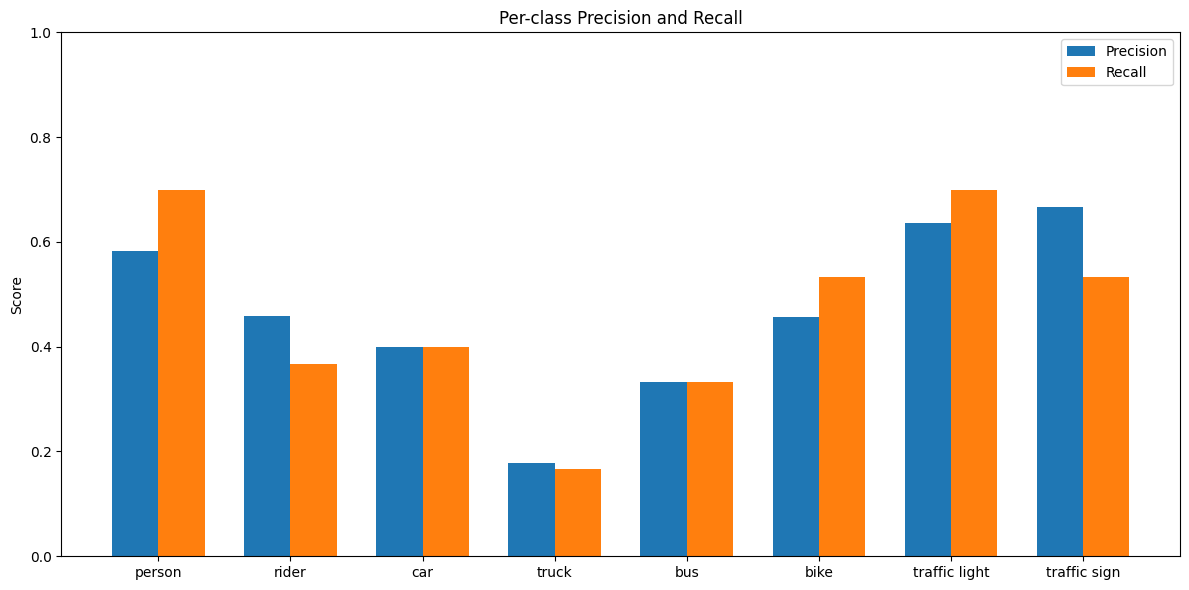

In [27]:
# Per class evaluation on the corrupted dataset (shuffled patches)
validation_data_loader = DataLoader(dataset=validate_dataset, batch_size=32)
per_class_precision_corrupted, per_class_recall_corrupted = evaluate_per_class(model, validation_data_loader, 
                                                                               validate_dataset.classes, validate_dataset.labels, visualize=True)

# Model performs best for the "traffic_light" class with a precision and recall of 0.66
# Model performs worst for the "bus" class (precision=0.26, recall=0.26) and the "truck" class (precision=0.36, recall=0.23) 

In [28]:
# Here, the agregated metrics are the same for both the corrupted dataset and the clean dataset.
# This means that the model is invariant to the positions of the patches, and as a result, predicts the
# same labels.
print("Agregated metrics for corrupted dataset:")
# Macro Prec = The mean per-class precision scores | Macro Recall = Same but for recall
macro_prec_corrupt, macro_recall_corrupt = agregate_per_class_metrics(per_class_precision_corrupted, per_class_recall_corrupted)

per_class_precision_clean, per_class_recall_clean = evaluate_per_class(model, test_data_loader, test_dataset.classes, test_dataset.labels)

print("\nAgregated metrics for clean dataset:")
macro_prec_clean, macro_recall_clean = agregate_per_class_metrics(per_class_precision_clean, per_class_recall_clean)

Agregated metrics for corrupted dataset:

Macro precision: 0.4642
Macro recall:    0.4667

Agregated metrics for clean dataset:

Macro precision: 0.4642
Macro recall:    0.4667


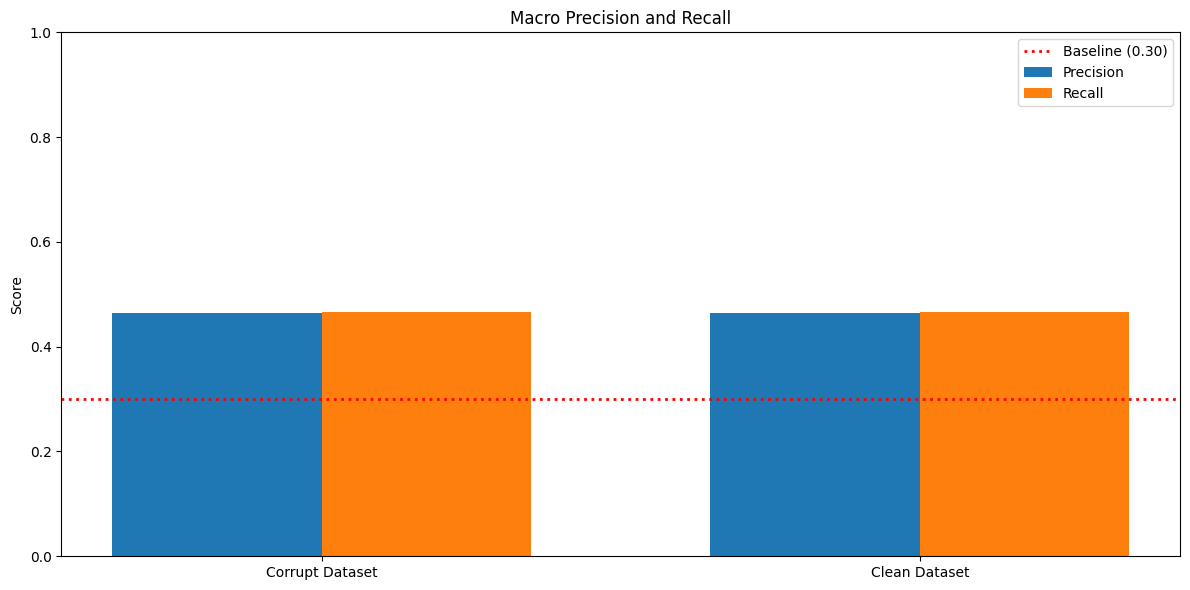

In [29]:
# Visualization
x = np.arange(2)
width = 0.35

precision_values = np.array([macro_prec_corrupt, macro_prec_clean])
recall_values = np.array([macro_recall_corrupt, macro_recall_clean])

plt.figure(figsize=(12, 6))

plt.bar(x - width / 2, precision_values, width, label="Precision")
plt.bar(x + width / 2, recall_values, width, label="Recall")
# Baseline of 0.3 as described by the task
plt.axhline(
    y=0.3,
    linestyle="dotted",
    linewidth=2,
    color="red",
    label=f"Baseline ({0.3:.2f})"
)

plt.xticks(x, ["Corrupt Dataset", "Clean Dataset"])
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Macro Precision and Recall")
plt.legend()
plt.tight_layout()

plt.savefig("macro_precision_recall_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 3 

In [31]:
# Get indices of where classes begin/end
class_to_idx = defaultdict(list)

for idx in range(len(train_dataset)):
    _, label = train_dataset[idx]
    class_name = train_dataset.id_to_class[label]
    class_to_idx[class_name].append(idx)

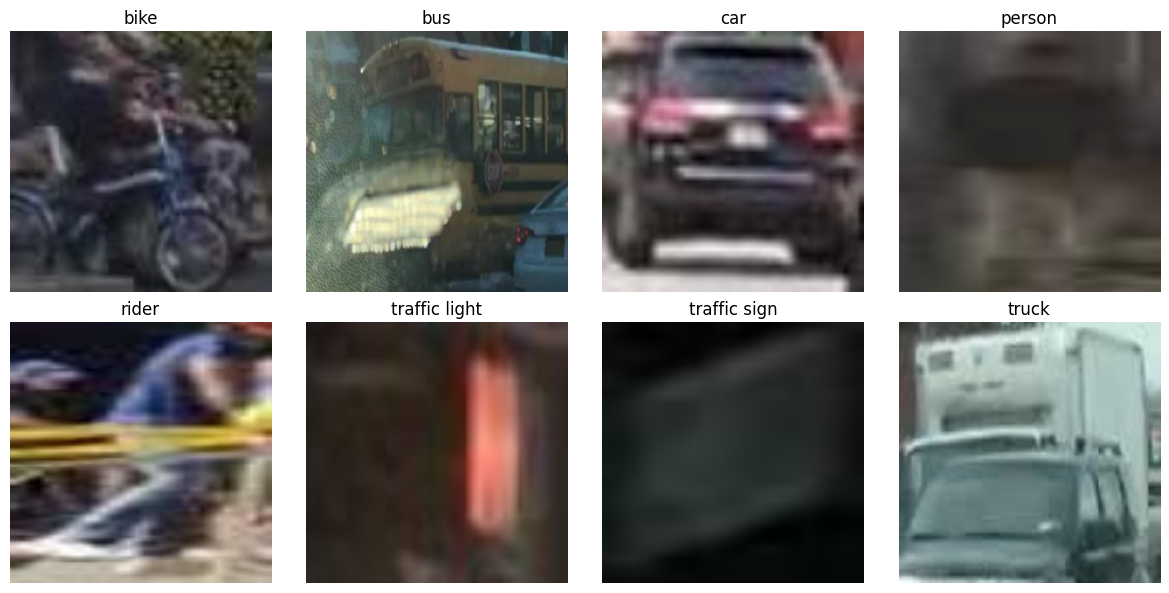

In [38]:
# Denormalize before plotting
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

# Plot one sample of each class
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

classes = sorted(train_dataset.classes)

for i, cls in enumerate(classes):
    idx = class_to_idx[cls][16]

    img_pre, label = train_dataset[idx]
    img = denormalize(img_pre).clamp(0, 1)

    img = img.permute(1, 2, 0).cpu().numpy()

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [39]:
# This utility class is aimed to help you a bit with the linear probe classifier.
# You can choose whether to implement it or not!


class LinearProbeClassifier(nn.Module):
    """
    Frozen pretrained backbone + trainable linear classification head.

    TODO:
    - load a pretrained backbone,
    - remove/replace its original classification head (if any),
    - freeze the backbone parameters,
    - add a new trainable linear head for the BDD classes.
    """

    def __init__(self, num_classes: int = 8):
        super().__init__()
        # Load pretrained model backbone (ignore backbone_arch string)
        self.backbone = SwinModel.from_pretrained("microsoft/swin-large-patch4-window7-224")

        # TODO: Sometimes the pretrained backbone may already have a classification head (e.g. ResNet's fc layer, ViT's heads layer). 
        # In this case you might need to replace it with an Identity layer to get the features before the head.
        # The Identity layer is simply a placeholder for the Identity function, which returns its input unchanged.
        # --> SwinModel loads without a classification head

        # Get hidden dimension size for linear head
        hidden_size = self.backbone.config.hidden_size
        
        # TODO: freeze all pretrained backbone parameters. Freezing a parameter means that it will not be updated during gradient updates.
        for param in self.backbone.parameters():
            param.requires_grad = False

        # TODO: define the trainable linear classification head
        self.linear_head = nn.Linear(hidden_size, num_classes)

    def forward(self, x: torch.Tensor):
        # The backbone should be used as a feature extractor.
        # No gradient tracking during forward
        with torch.no_grad():
            outputs = self.backbone(x)

        # Avg pooling on last layer hidden-state
        features = outputs.pooler_output

        # Then the features from the backbone are passed through the linear head to get the final logits for classification.
        logits = self.linear_head(features)

        return logits

In [40]:
def compute_macro_metrics(y_true, y_pred, num_classes=8):
    """Compute macro precision and recall over num_classes classes."""
    y_true = torch.cat(y_true).cpu()
    y_pred = torch.cat(y_pred).cpu()

    eps = 1e-8  # epsilon value to avoid div by zero
    precision_per_class = []
    recall_per_class = []

    # Get per-class precision and recall
    for c in range(num_classes):
        tp = ((y_pred == c) & (y_true == c)).sum().item()
        fp = ((y_pred == c) & (y_true != c)).sum().item()
        fn = ((y_pred != c) & (y_true == c)).sum().item()

        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)

        precision_per_class.append(precision)
        recall_per_class.append(recall)

    macro_precision = np.mean(precision_per_class)
    macro_recall = np.mean(recall_per_class)

    return macro_precision, macro_recall

In [41]:
# This code is taken and adapted from Practical P2.2.
class Trainer_task3():
    def __init__(self,
                 model: torch.nn.Module,
                 device: torch.device,
                 criterion: torch.nn.Module,
                 optimizer: torch.optim.Optimizer,
                 training_DataLoader: torch.utils.data.Dataset,
                 validation_DataLoader: torch.utils.data.Dataset,
                 epochs: int,
                 criterion_validation: torch.nn.Module = None,
                 ):

        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.training_DataLoader = training_DataLoader
        self.validation_DataLoader = validation_DataLoader
        self.device = device
        self.epochs = epochs

        if criterion_validation is None:
            self.criterion_validation = criterion
        else: 
            self.criterion_validation = criterion_validation

    def run_trainer(self):
        """Training for all epochs. Returns training history."""
        
        # Dictionary to save training history
        history = {
            "train_loss": [],
            "val_loss": [],
            "macro_precision": [],
            "macro_recall": []
        }
        
        # Train and validate with loading bar
        for epoch in tqdm(range(1, self.epochs+1)):
            # Training
            self.model.train()
            train_losses = []

            for batch in self.training_DataLoader:
                x, y = batch
                input, target = x.to(self.device), y.to(self.device)
                self.optimizer.zero_grad()
                out = self.model(input)
                loss = self.criterion(out, target)

                loss_value = loss.item()
                train_losses.append(loss_value)

                loss.backward()
                self.optimizer.step()

            # Validation
            self.model.eval()
            
            valid_losses = []
            all_true = []
            all_pred = []
            
            with torch.no_grad():
                for batch in self.validation_DataLoader:
                    x, y = batch
                    inputs = x.to(self.device)
                    targets = y.to(self.device)
            
                    out = self.model(inputs)
                    loss = self.criterion_validation(out, targets)
            
                    valid_losses.append(loss.item())
            
                    preds = out.argmax(dim=1)
            
                    all_true.append(targets.cpu())
                    all_pred.append(preds.cpu())
            
            macro_precision, macro_recall = compute_macro_metrics(all_true, all_pred, num_classes=8)
            avg_train_loss = np.mean(train_losses)
            avg_val_loss = np.mean(valid_losses)

            history["train_loss"].append(avg_train_loss)
            history["val_loss"].append(avg_val_loss)
            history["macro_precision"].append(macro_precision)
            history["macro_recall"].append(macro_recall)
                
            print(
                f'EPOCH: {epoch:0>{len(str(self.epochs))}}/{self.epochs}',
                end=' '
            )
            print(f'LOSS: {avg_train_loss:.4f}', end=' ')
            print(f'VAL-LOSS: {avg_val_loss:.4f}', end=' ')
            print(f'MACRO-PRECISION: {macro_precision:.4f}', end=' ')
            print(f'MACRO-RECALL: {macro_recall:.4f}')

        return history

In [42]:
# Create dataloaders
train_loader3 = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader3 = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [43]:
## Linear probing via training
linprob_model = LinearProbeClassifier(num_classes=8).to(device)

# Same as Task 1
criterion3 = nn.CrossEntropyLoss()
optimizer3 = torch.optim.AdamW(linprob_model.parameters(), lr=1e-3, weight_decay=1e-4)

# 10 epochs max for the linear head training
# Can use fewer to avoid overfitting
trainer = Trainer_task3(
    model=linprob_model,
    device=device,
    criterion=criterion3,
    optimizer=optimizer3,
    training_DataLoader=train_loader3,
    validation_DataLoader=test_loader3,
    epochs=10
)

history_lin = trainer.run_trainer()

# torch.save(linprob_model.state_dict(), "task_3_linear_probe_v3.pth")

Loading weights:   0%|          | 0/423 [00:00<?, ?it/s]

[transformers] SwinModel LOAD REPORT from: microsoft/swin-large-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
 10%|████████▎                                                                          | 1/10 [01:20<12:08, 80.95s/it]

EPOCH: 01/10 LOSS: 1.1758 VAL-LOSS: 0.8533 MACRO-PRECISION: 0.7341 MACRO-RECALL: 0.7292


 20%|████████████████▌                                                                  | 2/10 [02:41<10:46, 80.86s/it]

EPOCH: 02/10 LOSS: 0.7250 VAL-LOSS: 0.7636 MACRO-PRECISION: 0.7463 MACRO-RECALL: 0.7417


...

EPOCH: 08/10 LOSS: 0.3887 VAL-LOSS: 0.6840 MACRO-PRECISION: 0.7557 MACRO-RECALL: 0.7500


 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [12:17<01:22, 82.10s/it]

EPOCH: 09/10 LOSS: 0.3630 VAL-LOSS: 0.6765 MACRO-PRECISION: 0.7426 MACRO-RECALL: 0.7417


100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [13:39<00:00, 81.92s/it]

EPOCH: 10/10 LOSS: 0.3469 VAL-LOSS: 0.6926 MACRO-PRECISION: 0.7459 MACRO-RECALL: 0.7375


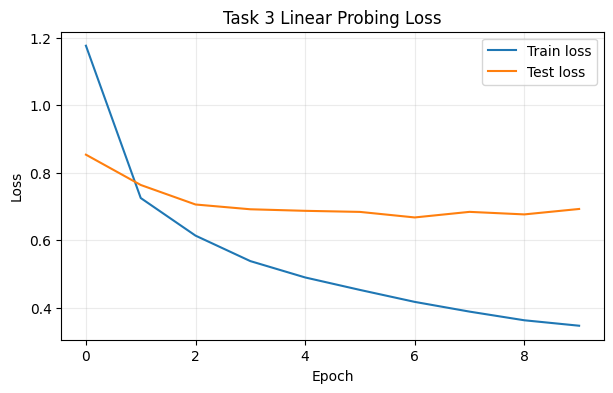

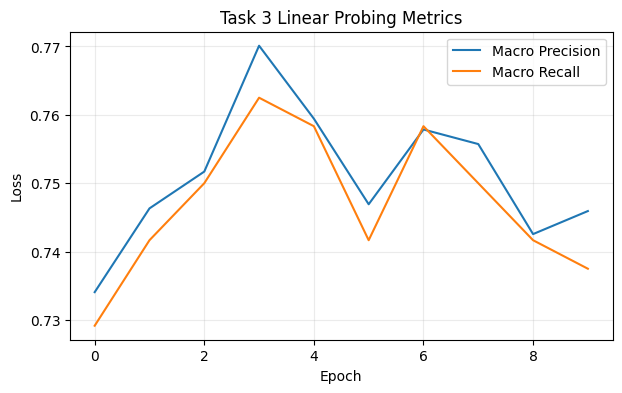

In [44]:
# Plotting to check overfitting
plt.figure(figsize=(7, 4))
plt.plot(history_lin["train_loss"], label="Train loss")
plt.plot(history_lin["val_loss"], label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 3 Linear Probing Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_lin["macro_precision"], label="Macro Precision")
plt.plot(history_lin["macro_recall"], label="Macro Recall")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task 3 Linear Probing Metrics")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [45]:
## kNN classification on backbone
# Get linear probing backbone to save memory
knn_model = linprob_model.backbone
knn_model.eval()

SwinModel(
  (embeddings): SwinEmbeddings(
    (patch_embeddings): SwinPatchEmbeddings(
      (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
    )
    (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): SwinEncoder(
    (layers): ModuleList(
      (0): SwinStage(
        (blocks): ModuleList(
          (0): SwinLayer(
            (attention): SwinAttention(
              (q_proj): Linear(in_features=192, out_features=192, bias=True)
              (k_proj): Linear(in_features=192, out_features=192, bias=True)
              (v_proj): Linear(in_features=192, out_features=192, bias=True)
              (o_proj): Linear(in_features=192, out_features=192, bias=True)
              (relative_position_bias): SwinRelativePositionBias()
            )
            (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
            (layernorm_after): LayerNorm((192,), eps=1e-05, elementwise_affi

In [46]:
# This code is adapted from Practical P2.2.
def extract_embeddings(model, dataloader, device):
    """Function to extract embeddings."""
    embeddings = []
    labels = []

    model.eval()
    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            # Adjustement to fit Swin model architecture
            outputs = model(images)
            emb = outputs.pooler_output

            embeddings.append(emb)
            labels.append(targets)

    # Leave CPU conversion for after the for loop for faster extraction
    embeddings = torch.cat(embeddings, dim=0).cpu()
    labels = torch.cat(labels, dim=0).cpu()

    return embeddings, labels

In [47]:
## This code is taken from this website: https://www.datasciencebase.com/supervised-ml/algorithms/k-nearest-neighbors/pytorch-example/
# Define the function to calculate Euclidean distance
def euclidean_distance(X_train, X_test_point):
    # Subtract the test point from each training point and compute the squared distances
    distances = torch.sum((X_train - X_test_point) ** 2, axis=1)
    return torch.sqrt(distances)

# Define the KNN classifier function
def knn(X_train, y_train, X_test, K):
    y_pred = []
    
    for X_test_point in X_test:
        # Compute distances from the test point to all training points
        distances = euclidean_distance(X_train, X_test_point)
        
        # Get the indices of the K nearest neighbors
        nearest_neighbors = torch.argsort(distances)[:K]
        
        # Get the labels of the K nearest neighbors
        nearest_labels = y_train[nearest_neighbors]
        
        # Perform a majority vote to predict the label
        predicted_label = torch.mode(nearest_labels).values.item()
        y_pred.append(predicted_label)
    
    return torch.tensor(y_pred)

In [48]:
# Get embeddings
train_embeddings, train_labels = extract_embeddings(knn_model, train_loader3, device)
test_embeddings, test_labels = extract_embeddings(knn_model, test_loader3, device)

In [49]:
# Run kNN and get precision and recall metrics
predictions = knn(train_embeddings, train_labels, test_embeddings, K=5)

precision_knn = precision_score(test_labels, predictions, average="macro")
recall_knn = recall_score(test_labels, predictions, average="macro")

print(f"Final kNN macro precision: \t{precision_knn}\nFinal kNN macro recall: \t{recall_knn}")

Final kNN macro precision: 	0.6347001190751191
Final kNN macro recall: 	0.6291666666666667


In [50]:
## Final visualization
# Task 2 final recall and precision
# TODO: get results for barplot, has placeholders for plotting
final_recall_task2 = macro_recall_clean
final_prec_task = macro_prec_clean

# Linear probe
final_recall_lp = history_lin["macro_recall"][-1]
final_prec_lp = history_lin["macro_precision"][-1]

# kNN final results
final_recall_knn = recall_knn
final_prec_knn = precision_knn

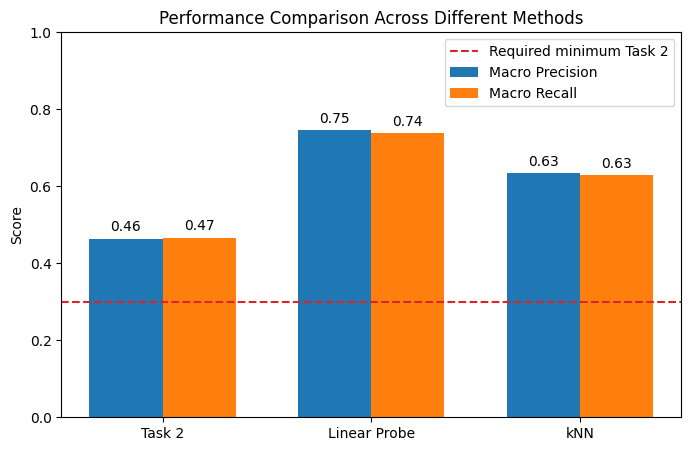

In [51]:
# Organize data for plotting
methods = ["Task 2", "Linear Probe", "kNN"]

recall = [final_recall_task2, final_recall_lp, final_recall_knn]
precision = [final_prec_task, final_prec_lp, final_prec_knn]

# Bar chart with 6 bars, 3 methods * 2 metrics
x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(8, 5))

# Add bars with metric values per bar
bars1 = plt.bar(x - width/2, precision, width, label="Macro Precision")
bars2 = plt.bar(x + width/2, recall, width, label="Macro Recall")

ax = plt.gca()
ax.bar_label(bars1, fmt="%.2f", padding=3)
ax.bar_label(bars2, fmt="%.2f", padding=3)

# Task 2 minimum is 0.3 for both, so a line is added for distinction
plt.axhline(0.3, linestyle="--", color="tab:red", label="Required minimum Task 2")

plt.xticks(x, methods)
plt.ylabel("Score")
plt.title("Performance Comparison Across Different Methods")
plt.ylim(0, 1.0)
plt.legend()
plt.savefig(
        "task3_comparison bar plot.png",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()